# Del *spike* al *estado neuronal*: entendiendo la codificación de poblaciones
## Tutorial práctico con datos reales del Allen Visual Coding – Neuropixels (DANDI:000021)

Este notebook es una guía de aprendizaje que recorre, paso a paso, el puente conceptual y práctico que une dos ideas centrales de la neurociencia de sistemas:

1. El **spike** (potencial de acción) de una **neurona individual**, que es el dato más crudo que registramos.
2. El **estado neuronal** (o *neural state*) de una **población** de neuronas, que vive en un **espacio latente** de baja dimensión y describe el comportamiento *colectivo* del circuito.

Trabajaremos con datos **reales** del *Allen Institute – Visual Coding – Neuropixels* (dandiset `000021`), registrados en la corteza visual de ratón mientras se le presentaban estímulos visuales.

### Cómo está organizado el tutorial

- **Sección 1 — Introducción conceptual:** ¿qué es un estado neuronal? De la codificación de una neurona a la codificación de poblaciones.
- **Sección 2 — Carga de datos crudos (spikes):** streaming del archivo NWB desde DANDI y extracción de los spikes de una región concreta (corteza visual primaria, VISp).
- **Sección 3 — Binning y tasas de disparo:** de tiempos discretos de spikes a tasas de disparo continuas (con suavizado gaussiano).
- **Sección 4 — El espacio de estados de alta dimensionalidad:** la idea de un espacio de N dimensiones (una por neurona).
- **Sección 5 — Reducción de dimensionalidad (PCA):** cómo extraer las *variables latentes* (componentes principales).
- **Sección 6 — Trayectorias del estado neuronal:** visualización del estado de la población a lo largo del tiempo en 2D y 3D.

> **Nota de rendimiento.** El archivo NWB de una sesión ocupa varios GB, pero **no lo descargamos entero**: usamos *streaming* (con `remfile`) para leer de la nube únicamente los trozos que necesitamos, y además restringimos el análisis a **una sesión**, **una región (VISp)** y **una ventana temporal corta**. Así el notebook es ligero con la RAM.

---
## Sección 1: Introducción Conceptual

### 1.1. El punto de partida: una neurona y sus *spikes*

El cerebro se comunica mediante **potenciales de acción** o *spikes*: pulsos eléctricos breves (~1 ms) y esencialmente idénticos entre sí. Como todos los spikes se parecen, la información **no** está en la *forma* del spike, sino en **cuándo** y **con qué frecuencia** ocurren. Por eso, para una neurona, el dato fundamental es una **lista de tiempos de disparo** (`spike_times`).

Durante décadas, la neurociencia estudió neuronas de una en una y buscó su **curva de sintonía** (*tuning curve*): la relación entre una variable del mundo (por ejemplo, la orientación de una rejilla visual) y la tasa de disparo de esa neurona. Este es el paradigma de la **codificación de neurona única** (*single-neuron coding*): cada neurona *representa* una característica concreta del estímulo.

### 1.2. El problema: el cerebro no funciona neurona a neurona

La codificación de neurona única tiene límites importantes:

- **Variabilidad:** ante el *mismo* estímulo repetido, una misma neurona dispara un número distinto de spikes cada vez (ruido, estado interno, atención...). Mirando una sola neurona es difícil separar señal de ruido.
- **Ambigüedad:** muchas neuronas responden a *varias* características a la vez (codificación mixta). La respuesta de una neurona aislada casi nunca identifica de forma única lo que está pasando.
- **La computación es colectiva:** las decisiones, los movimientos y las percepciones emergen de la actividad **conjunta** de miles de neuronas, no de una sola.

La idea clave es que **la información redundante y distribuida** entre muchas neuronas es mucho más robusta y expresiva que la de cualquier neurona individual.

### 1.3. La solución: la codificación de poblaciones y el *estado neuronal*

Cambiemos de perspectiva. En lugar de N curvas de sintonía independientes, consideremos las N neuronas **a la vez**. En cada instante de tiempo podemos escribir un **vector** con la tasa de disparo de cada neurona:

$$\; \mathbf{r}(t) = [\, r_1(t),\; r_2(t),\; \dots,\; r_N(t) \,] \;$$

Ese vector `r(t)` es el **estado neuronal** (*neural state*) en el instante `t`. Es un **punto** en un espacio de N dimensiones, donde cada eje es una neurona. A medida que pasa el tiempo, el punto se mueve y dibuja una **trayectoria**: la dinámica de la población.

### 1.4. La gran observación: la actividad vive en un espacio de baja dimensión

Aunque registremos N = cientos de neuronas (N dimensiones), sus actividades **no son independientes**: las neuronas están conectadas y comparten entradas, así que se correlacionan fuertemente. En la práctica, la nube de estados `r(t)` no llena todo el espacio de N dimensiones, sino que se concentra cerca de una **superficie curva de pocas dimensiones**, llamada **variedad neuronal** (*neural manifold*).

Esto significa que unas pocas **variables latentes** (mucho menos que N) bastan para describir casi toda la actividad de la población. Encontrar esas variables latentes es exactamente el objetivo de la **reducción de dimensionalidad** (Sección 5), y la técnica más habitual para empezar es el **Análisis de Componentes Principales (PCA)**.

### 1.5. El plan de este tutorial en una frase

> Partiremos de los **spikes crudos** de muchas neuronas de VISp → los convertiremos en una **matriz de tasas de disparo** (neuronas × tiempo) → interpretaremos cada instante como un **punto en un espacio de N dimensiones** → y con **PCA** proyectaremos ese espacio a 2–3 dimensiones para **ver la trayectoria** del estado neuronal.

A lo largo del camino explicaremos *por qué* tomamos cada decisión, no solo *qué* hacemos.

---
## Sección 2: Carga de Datos Crudos (Spikes de DANDI:000021)

### 2.1. ¿Qué es NWB y por qué usamos *streaming*?

Los datos se distribuyen en formato **NWB** (*Neurodata Without Borders*), un estándar basado en HDF5 que guarda, dentro de un único archivo, tanto los datos como los metadatos de una sesión experimental. En DANDI, el dandiset `000021` contiene una sesión por sujeto y, además, un archivo por sonda (*probe*).

El **archivo de sesión** (`sub-XXX_ses-YYY.nwb`) es el que nos interesa porque contiene la tabla `units`: los **spikes ya ordenados** (*spike sorting*) de todas las neuronas de todas las sondas, junto con la tabla `electrodes`, que nos dice en qué **región cerebral** está cada canal.

Como estos archivos pesan varios GB, en lugar de descargarlos usamos el patrón de **streaming** recomendado por DANDI (el mismo que aparece en tus `Example_codes/advanced_io/streaming.py`): abrimos el archivo remoto con `remfile`, lo envolvemos con `h5py` y lo leemos con `pynwb`. Así solo viajan por la red los bytes que realmente pedimos.

### 2.2. Primero, las librerías del entorno

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Paquetes de streaming NWB / DANDI (los mismos que usas en tu entorno) ---
import h5py
import remfile
import pynwb
from dandi.dandiapi import DandiAPIClient

# --- Paquetes opcionales: los intentamos importar y avisamos si faltan ---
# El notebook funciona aunque no estén (tiene alternativas caseras con numpy).
TIENE_SCIPY = False
TIENE_SKLEARN = False
TIENE_SEABORN = False
try:
    from scipy.ndimage import gaussian_filter1d
    TIENE_SCIPY = True
except Exception:
    print('AVISO: scipy no está instalado -> usaré un suavizado gaussiano casero (numpy).')
    print('       Para instalarlo:  pip install scipy')
try:
    from sklearn.decomposition import PCA
    TIENE_SKLEARN = True
except Exception:
    print('AVISO: scikit-learn no está instalado -> usaré PCA vía SVD de numpy.')
    print('       Para instalarlo:  pip install scikit-learn')
try:
    import seaborn as sns
    sns.set_theme(style='whitegrid', context='notebook')
    TIENE_SEABORN = True
except Exception:
    print('AVISO: seaborn no está instalado -> usaré matplotlib para los mapas de calor.')
    print('       Para instalarlo:  pip install seaborn')

print()
print('Versiones principales del entorno:')
print('  numpy   :', np.__version__)
print('  pandas  :', pd.__version__)
print('  pynwb   :', pynwb.__version__)
print('  h5py    :', h5py.__version__)
print('  remfile :', remfile.__version__)


Versiones principales del entorno:
  numpy   : 2.5.1
  pandas  : 3.0.3
  pynwb   : 4.0.0
  h5py    : 3.16.0
  remfile : 0.1.13


### 2.3. Configuración del tutorial

Reunimos en una sola celda todos los parámetros que puedes cambiar. Elegimos deliberadamente **la misma sesión** que ya exploraste en `behavioral_exploration.ipynb` para mantener la coherencia con tu trabajo previo. Los valores de *binning*, suavizado y control de calidad siguen las convenciones habituales para este dataset (Allen Institute / *Openscope Databook*), que explicaremos cuando los usemos.

In [5]:
# ============================================================
#  CONFIGURACIÓN DEL TUTORIAL  (puedes editar estos valores)
# ============================================================
DANDISET_ID    = '000021'                                          # Allen Visual Coding - Neuropixels
DANDI_FILEPATH = 'sub-738651046/sub-738651046_ses-760693773.nwb'   # una sesión concreta

REGION_OBJETIVO = 'VISp'      # corteza visual primaria (acrónimo del atlas Allen CCF)

TAMANO_BIN       = 0.050      # tamaño del bin temporal, en segundos (50 ms)
SIGMA_SUAVIZADO  = 0.100      # sigma del filtro gaussiano, en segundos (100 ms)
DURACION_VENTANA = 60.0       # duración de la ventana de análisis, en segundos

# Criterios de calidad estándar del Allen Institute (spike-sorting QC)
QC_ISI_VIOLATIONS_MAX   = 0.5
QC_AMPLITUDE_CUTOFF_MAX = 0.1
QC_PRESENCE_RATIO_MIN   = 0.9

### 2.4. Localizar el archivo en DANDI y abrirlo por *streaming*

El `DandiAPIClient` nos da la **URL S3** del archivo. Con esa URL abrimos el archivo remoto sin descargarlo. La primera lectura tarda unos segundos porque `pynwb` lee la *estructura* del archivo (los metadatos), pero los datos pesados (spikes, LFP...) se leen **de forma perezosa** (*lazy*): solo cuando los pedimos explícitamente.

In [6]:
# Obtenemos la URL S3 del archivo NWB dentro del archivo DANDI.
with DandiAPIClient() as client:
    dandiset = client.get_dandiset(DANDISET_ID, 'draft')
    asset = dandiset.get_asset_by_path(DANDI_FILEPATH)
    s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)

print('Sesión :', DANDI_FILEPATH)
print('URL S3 :', s3_url)

Sesión : sub-738651046/sub-738651046_ses-760693773.nwb
URL S3 : https://dandiarchive.s3.amazonaws.com/blobs/4dd/fc6/4ddfc61e-7c06-47d0-9057-f53d70943cd3


In [7]:
# Patrón de streaming recomendado por DANDI: remfile + h5py + pynwb.
# NO descarga los ~3 GB: solo lee de la nube los trozos que pidamos.
rem_file = remfile.File(s3_url)
h5_file  = h5py.File(rem_file, 'r')
io       = pynwb.NWBHDF5IO(file=h5_file, load_namespaces=True)
nwb      = io.read()

print('ID de sesión     :', nwb.session_id)
print('Inicio de sesión :', nwb.session_start_time)
print('Sujeto (ratón)   :', nwb.subject.subject_id, '|', nwb.subject.genotype)
print('Nº total unidades:', len(nwb.units.id[:]))
print('Sondas (probes)  :', list(nwb.electrode_groups.keys()))

ID de sesión     : 760693773
Inicio de sesión : 2018-10-26 12:59:23-07:00
Sujeto (ratón)   : 738651046 | Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt
Nº total unidades: 2285
Sondas (probes)  : ['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF']


### 2.5. De unidades a regiones: cómo saber qué neuronas están en VISp

La tabla `units` guarda cada neurona ordenada con muchas columnas de metadatos y sus `spike_times`. Pero, ¿cómo sabemos en qué **región** está cada neurona?

La estrategia estándar en Neuropixels es:

1. Cada unidad tiene un **canal de máxima amplitud** (`peak_channel_id`): el electrodo donde su spike se ve más grande. Ese canal es la mejor estimación de *dónde* está físicamente la neurona.
2. La tabla `electrodes` asigna a cada canal una **región cerebral** (columna `location`, con acrónimos del atlas Allen: `VISp`, `VISl`, `CA1`, `LGd`, ...).
3. Por tanto, unimos: `unidad → peak_channel_id → location`.

Un detalle importante de eficiencia: leemos solo las columnas **escalares** (un valor por neurona, arrays 1D pequeños) y **todavía no** los `spike_times` (que son muchos y pesados). Los spikes los leeremos más tarde, únicamente para las neuronas seleccionadas.

In [8]:
# --- Metadatos de las unidades (SIN cargar spike_times todavía) ---
colnames = list(nwb.units.colnames)
print('Columnas disponibles en la tabla units:')
print(colnames)

unit_ids = nwb.units.id[:]
columnas_meta = [c for c in ['peak_channel_id', 'quality', 'firing_rate', 'snr',
                             'isi_violations', 'amplitude_cutoff', 'presence_ratio']
                 if c in colnames]
meta = {c: nwb.units[c].data[:] for c in columnas_meta}
units_meta = pd.DataFrame(meta, index=pd.Index(unit_ids, name='unit_id'))

# --- Tabla de electrodos: incluye la REGIÓN cerebral de cada canal ---
electrodos = nwb.electrodes.to_dataframe()
print()
print('Columnas de la tabla de electrodos:', list(electrodos.columns))

# Mapeamos cada unidad a su región vía el canal de máxima amplitud (peak_channel_id).
if 'peak_channel_id' in units_meta.columns and 'location' in electrodos.columns:
    units_meta['location'] = units_meta['peak_channel_id'].map(electrodos['location'])
else:
    raise RuntimeError('No encuentro peak_channel_id o location; revisa las columnas impresas arriba.')

# quality a veces llega como bytes; lo pasamos a texto para poder comparar.
if 'quality' in units_meta.columns:
    units_meta['quality'] = units_meta['quality'].astype(str)

print()
print('Número de unidades por región (top 15):')
display(units_meta['location'].value_counts().head(15).to_frame('n_unidades'))

Columnas disponibles en la tabla units:
['quality', 'amplitude_cutoff', 'recovery_slope', 'cluster_id', 'spread', 'velocity_below', 'd_prime', 'nn_miss_rate', 'isolation_distance', 'silhouette_score', 'waveform_halfwidth', 'PT_ratio', 'cumulative_drift', 'isi_violations', 'presence_ratio', 'snr', 'l_ratio', 'amplitude', 'repolarization_slope', 'local_index', 'velocity_above', 'nn_hit_rate', 'peak_channel_id', 'waveform_duration', 'firing_rate', 'max_drift', 'spike_times', 'spike_amplitudes', 'waveform_mean']

Columnas de la tabla de electrodos: ['x', 'y', 'z', 'imp', 'location', 'filtering', 'group', 'group_name', 'probe_vertical_position', 'probe_horizontal_position', 'probe_id', 'local_index', 'valid_data']

Número de unidades por región (top 15):


,n_unidades
location,
grey,1390
VISal,279
VISp,217
VISrl,147
VISam,138
VISpm,113
,1


### 2.6. Seleccionar VISp y aplicar control de calidad (QC)

Nos quedamos con las unidades de `VISp` que superan el **control de calidad** del *spike sorting*. Filtrar por calidad es fundamental: si incluimos unidades mal aisladas (que en realidad mezclan varias neuronas o son ruido), el estado neuronal quedaría contaminado. Los umbrales que usamos son los **valores por defecto del Allen Institute**:

- `quality == 'good'`: la unidad pasó el criterio de aislamiento del algoritmo.
- `isi_violations ≤ 0.5`: pocas violaciones del período refractario (indicador de una sola neurona).
- `amplitude_cutoff ≤ 0.1`: pocos spikes perdidos por caer bajo el umbral de detección.
- `presence_ratio ≥ 0.9`: la unidad estuvo presente durante casi toda la sesión (no apareció/desapareció por deriva del electrodo).

Aplicamos cada filtro solo si su columna existe, para que el código sea robusto.

In [9]:
mascara = units_meta['location'] == REGION_OBJETIVO

if 'quality' in units_meta.columns:
    mascara &= units_meta['quality'] == 'good'
if 'isi_violations' in units_meta.columns:
    mascara &= units_meta['isi_violations'] <= QC_ISI_VIOLATIONS_MAX
if 'amplitude_cutoff' in units_meta.columns:
    mascara &= units_meta['amplitude_cutoff'] <= QC_AMPLITUDE_CUTOFF_MAX
if 'presence_ratio' in units_meta.columns:
    mascara &= units_meta['presence_ratio'] >= QC_PRESENCE_RATIO_MIN

unidades_sel  = units_meta[mascara]
posiciones_sel = np.where(mascara.values)[0]   # índices de fila para leer spike_times después

print(f'Unidades en {REGION_OBJETIVO} que superan el QC: {len(unidades_sel)}')
if len(unidades_sel) < 10:
    print()
    print('AVISO: hay muy pocas unidades. Regiones con más unidades en esta sesión:')
    print(units_meta['location'].value_counts().head(10))
    print('Puedes cambiar REGION_OBJETIVO en la celda de configuración.')

display(unidades_sel.head())

Unidades en VISp que superan el QC: 92


,peak_channel_id,quality,firing_rate,snr,isi_violations,amplitude_cutoff,presence_ratio,location
unit_id,,,,,,,,
951791719,850088626,good,0.104840,3.141620,0.000000,0.061289,0.94,VISp
951791461,850088614,good,0.907548,2.719859,0.375749,0.005772,0.99,VISp
951790421,850088614,good,1.583539,4.014420,0.046271,0.000017,0.99,VISp
951790273,850088614,good,0.373028,2.342606,0.000000,0.003293,0.98,VISp
951790678,850088632,good,0.539885,5.405894,0.000000,0.005381,0.99,VISp


### 2.7. Elegir una ventana temporal durante un estímulo visual

El estado neuronal es más interesante (y sus trayectorias más estructuradas) cuando el cerebro *está haciendo algo*. Por eso restringimos el análisis a una ventana temporal **dentro de un bloque de estímulo visual**. Usamos las **rejillas en movimiento** (*drifting gratings*), un estímulo clásico que activa de forma fuerte y reproducible a la corteza visual primaria. Si ese bloque no existiera, el código elige automáticamente el primer estímulo disponible.

Restringir la ventana también ayuda a la RAM: en vez de toda la sesión (~1 hora), analizamos solo unos 60 segundos.

In [10]:
print('Bloques de estímulo (intervals) disponibles en la sesión:')
print(list(nwb.intervals.keys()))

nombre_estimulo = 'drifting_gratings_presentations'
if nombre_estimulo not in nwb.intervals:
    nombre_estimulo = list(nwb.intervals.keys())[0]   # plan B: el primero que haya

estim    = nwb.intervals[nombre_estimulo].to_dataframe()
T_INICIO = float(estim['start_time'].iloc[0])
T_FIN    = T_INICIO + DURACION_VENTANA

print()
print(f'Estímulo elegido  : {nombre_estimulo}')
print(f'Ventana de análisis: [{T_INICIO:.1f} s, {T_FIN:.1f} s]  (duración {DURACION_VENTANA:.0f} s)')

Bloques de estímulo (intervals) disponibles en la sesión:
['drifting_gratings_presentations', 'flashes_presentations', 'gabors_presentations', 'natural_movie_one_presentations', 'natural_movie_three_presentations', 'natural_scenes_presentations', 'spontaneous_presentations', 'static_gratings_presentations']

Estímulo elegido  : drifting_gratings_presentations
Ventana de análisis: [1580.1 s, 1640.1 s]  (duración 60 s)


### 2.8. Extraer los spikes y dibujar el *raster plot*

Ahora sí leemos los `spike_times`, pero **solo** de las neuronas seleccionadas y **solo** dentro de la ventana. `nwb.units['spike_times'][pos]` aprovecha los índices internos del archivo HDF5 para traer de la nube únicamente los spikes de esa neurona.

El **raster plot** es la visualización más honesta del dato crudo: cada fila es una neurona y cada marca vertical es un spike. Es el retrato de la actividad *antes* de cualquier procesamiento.

In [11]:
# Extraemos spike_times por neurona, recortados a la ventana [T_INICIO, T_FIN).
spikes_por_unidad = []
for pos in posiciones_sel:
    st = np.asarray(nwb.units['spike_times'][pos])
    st = st[(st >= T_INICIO) & (st < T_FIN)]
    spikes_por_unidad.append(st)

n_neuronas     = len(spikes_por_unidad)
n_spikes_total = int(sum(len(s) for s in spikes_por_unidad))
print(f'Neuronas: {n_neuronas} | Spikes totales en la ventana: {n_spikes_total}')

Neuronas: 92 | Spikes totales en la ventana: 25704


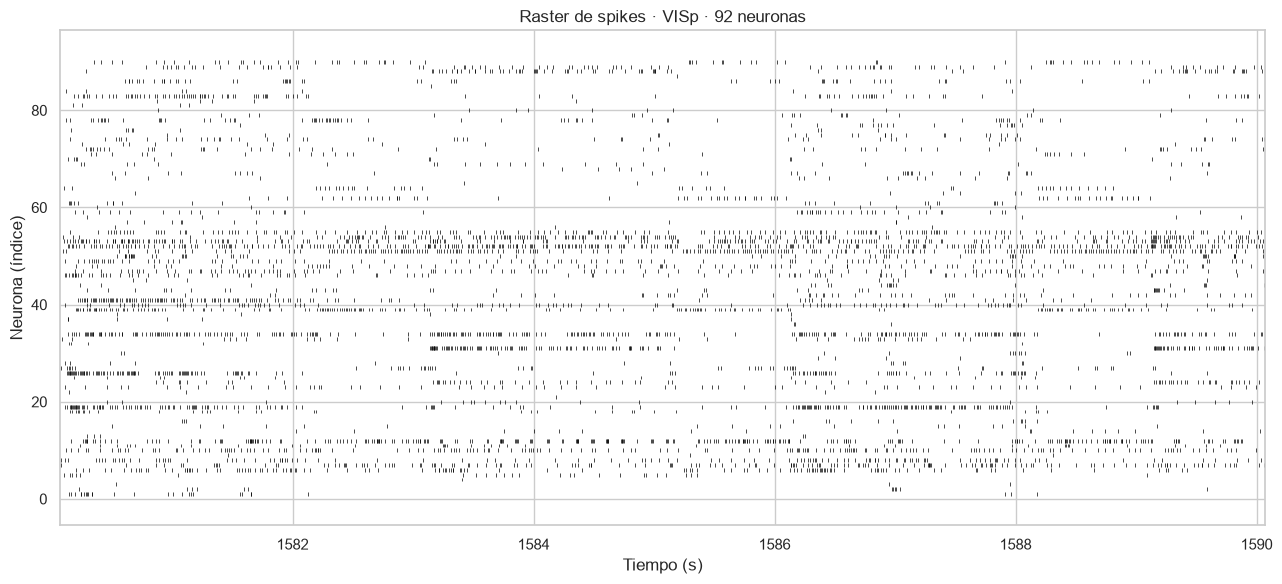

In [12]:
# --- Raster plot: cada fila una neurona, cada marca un spike ---
fig, ax = plt.subplots(figsize=(13, 6))
ax.eventplot(spikes_por_unidad, colors='black',
             lineoffsets=np.arange(n_neuronas), linelengths=0.8, linewidths=0.5)
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Neurona (índice)')
ax.set_title(f'Raster de spikes · {REGION_OBJETIVO} · {n_neuronas} neuronas')
# Mostramos solo los primeros 10 s para que las marcas se distingan bien.
ax.set_xlim(T_INICIO, T_INICIO + 10)
plt.tight_layout()
plt.show()

---
## Sección 3: Binning y Tasas de Disparo (Firing Rates)

### 3.1. ¿Por qué convertir spikes en tasas?

Un tren de spikes es una secuencia de tiempos discretos: matemáticamente incómodo (es una suma de deltas de Dirac). Para hacer álgebra lineal (correlaciones, PCA...) necesitamos representar la actividad como **números continuos** ordenados en el tiempo y **alineados** entre todas las neuronas (mismos instantes de muestreo). La solución clásica es el **binning**:

1. Dividimos el tiempo en ventanas iguales (*bins*) de tamaño fijo, p. ej. 50 ms.
2. Contamos cuántos spikes cae cada neurona en cada bin.
3. Dividimos por el tamaño del bin → obtenemos una **tasa de disparo** en Hz (spikes/segundo).

El resultado es una **matriz** de forma `(neuronas × bins)`: la materia prima de todo lo que sigue.

### 3.2. ¿Cómo elegir el tamaño del bin?

Es un compromiso (*bias–variance*):

- **Bins muy pequeños** (p. ej. 1 ms): gran resolución temporal, pero casi todos los bins valen 0 o 1 → mucho ruido.
- **Bins muy grandes** (p. ej. 1 s): señal suave, pero perdemos la dinámica rápida.

Para análisis de poblaciones y trayectorias de estado en corteza visual, es habitual usar bins de **decenas de milisegundos**. Aquí tomamos **50 ms**, una elección estándar y equilibrada para este tipo de datos.

In [13]:
# --- Binning: contamos spikes en bins de tamaño fijo y pasamos a Hz ---
bordes  = np.arange(T_INICIO, T_FIN + TAMANO_BIN, TAMANO_BIN)
centros = bordes[:-1] + TAMANO_BIN / 2.0      # tiempo del centro de cada bin
n_bins  = len(centros)

conteos = np.zeros((n_neuronas, n_bins))
for i, st in enumerate(spikes_por_unidad):
    conteos[i], _ = np.histogram(st, bins=bordes)

# De 'conteo por bin' a 'tasa de disparo' en Hz (spikes por segundo).
tasas = conteos / TAMANO_BIN

# Guardamos en un DataFrame: filas = neuronas, columnas = tiempo (centro del bin).
tasas_df = pd.DataFrame(tasas, index=unidades_sel.index, columns=np.round(centros, 3))
tasas_df.index.name   = 'unit_id'
tasas_df.columns.name = 'tiempo_s'

print('Forma de la matriz (neuronas × bins):', tasas_df.shape)
print('Primeras 5 neuronas × primeras 8 columnas de tiempo:')
display(tasas_df.iloc[:5, :8])

Forma de la matriz (neuronas × bins): (92, 1200)
Primeras 5 neuronas × primeras 8 columnas de tiempo:


tiempo_s,1580.099,1580.149,1580.199,1580.249,1580.299,1580.349,1580.399,1580.449
unit_id,,,,,,,,
951791719,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
951791461,0.0,40.0,20.0,60.0,60.0,40.0,0.0,0.0
951790421,0.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0
951790273,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
951790678,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 3.3. Suavizado: de un histograma escalonado a una tasa "instantánea"

El histograma de conteos es escalonado y ruidoso. La tasa de disparo *real* de una neurona es una función suave del tiempo; el binning solo es una estimación tosca. Para aproximarnos mejor, **suavizamos** cada tren temporal con un **filtro gaussiano**: sustituimos cada bin por un promedio ponderado de sus vecinos, dando más peso a los cercanos.

El parámetro clave es la **anchura** del filtro (`sigma`): cuánto miramos hacia los lados. Aquí usamos `sigma = 100 ms`, coherente con las convenciones habituales para este dataset. Suavizar reduce el ruido y hace que las **trayectorias** del estado neuronal (Sección 6) sean continuas y legibles, en lugar de un enjambre de puntos dispersos.

> Nota: `sigma` se expresa en segundos, pero el filtro trabaja en *bins*, así que convertimos `sigma_bins = sigma_segundos / tamaño_bin`.

In [14]:
def suavizar_gaussiano(matriz, sigma_bins):
    """Suaviza cada fila (neurona) a lo largo del tiempo con un filtro gaussiano."""
    if TIENE_SCIPY:
        return gaussian_filter1d(matriz, sigma=sigma_bins, axis=1, mode='nearest')
    # Alternativa casera con numpy si no hay scipy:
    radio  = int(np.ceil(3 * sigma_bins))
    x      = np.arange(-radio, radio + 1)
    nucleo = np.exp(-0.5 * (x / sigma_bins) ** 2)
    nucleo = nucleo / nucleo.sum()
    return np.vstack([np.convolve(fila, nucleo, mode='same') for fila in matriz])

sigma_bins   = SIGMA_SUAVIZADO / TAMANO_BIN
tasas_suaves = suavizar_gaussiano(tasas, sigma_bins)

tasas_suaves_df = pd.DataFrame(tasas_suaves, index=unidades_sel.index,
                               columns=np.round(centros, 3))
print(f'Sigma del suavizado: {SIGMA_SUAVIZADO*1000:.0f} ms  ({sigma_bins:.1f} bins)')
print('Primeras 5 neuronas (tasas suavizadas, Hz):')
display(tasas_suaves_df.iloc[:5, :8])

Sigma del suavizado: 100 ms  (2.0 bins)
Primeras 5 neuronas (tasas suavizadas, Hz):


,1580.099,1580.149,1580.199,1580.249,1580.299,1580.349,1580.399,1580.449
unit_id,,,,,,,,
951791719,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
951791461,15.318444,23.733112,31.487035,35.905625,35.123460,29.479344,21.540836,14.304779
951790421,1.295199,2.419750,3.520715,3.989493,3.520715,2.419750,1.295199,0.539919
951790273,0.000000,0.001338,0.008727,0.044319,0.175286,0.539919,1.295199,2.419750
951790678,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


### 3.4. Mapa de calor: toda la población de un vistazo

El *heatmap* muestra la matriz completa: cada fila es una neurona, cada columna un instante, y el color es la tasa. Para visualizar, aplicamos un **z-score por neurona** (restar su media y dividir por su desviación típica): así comparamos el *patrón temporal* de todas las neuronas en igualdad de condiciones, sin que las de tasa alta dominen la escala de color. Fíjate en las **bandas verticales**: momentos en que muchas neuronas suben o bajan a la vez. Esa **covariación** es justo la estructura que el PCA explotará.

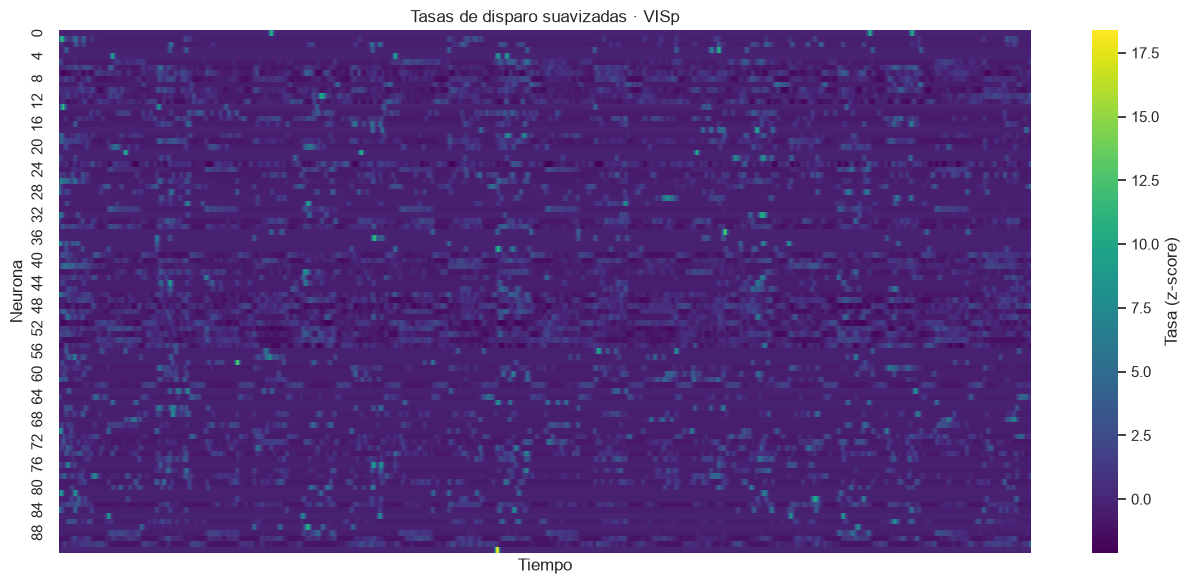

In [15]:
# z-score por neurona (solo para visualizar los patrones).
media = tasas_suaves.mean(axis=1, keepdims=True)
desv  = tasas_suaves.std(axis=1, keepdims=True) + 1e-9
z     = (tasas_suaves - media) / desv

fig, ax = plt.subplots(figsize=(13, 6))
if TIENE_SEABORN:
    sns.heatmap(z, cmap='viridis', ax=ax, cbar_kws={'label': 'Tasa (z-score)'})
    ax.set_xticks([])
else:
    im = ax.imshow(z, aspect='auto', cmap='viridis', origin='lower',
                   extent=[T_INICIO, T_FIN, 0, n_neuronas])
    fig.colorbar(im, ax=ax, label='Tasa (z-score)')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Neurona')
ax.set_title(f'Tasas de disparo suavizadas · {REGION_OBJETIVO}')
plt.tight_layout()
plt.show()

---
## Sección 4: El Espacio de Estados de Alta Dimensionalidad

### 4.1. Cada instante es un punto en un espacio de N dimensiones

Volvamos a la idea de la Sección 1, ahora con la matriz en la mano. Nuestra matriz de tasas suavizadas tiene forma `(N neuronas × T bins)`. Podemos leerla de dos maneras:

- **Por filas:** cada fila es la historia temporal de *una* neurona (lo que vimos en el heatmap).
- **Por columnas:** cada columna es el **estado de la población** en *un* instante: un vector de N números, es decir, **un punto en un espacio de N dimensiones** (uno por neurona).

Esta segunda lectura es la clave. Si tenemos `N = 80` neuronas, cada instante vive en un espacio ℝ⁸⁰. La actividad de la red a lo largo del tiempo es una **secuencia de puntos** en ese espacio: una **trayectoria**.

### 4.2. El problema y la esperanza

No podemos *ver* 80 dimensiones. Pero, como anticipamos, las neuronas están correlacionadas, así que los puntos no llenan todo ℝ⁸⁰: se concentran cerca de una **variedad** de pocas dimensiones. Antes de reducir formalmente con PCA, hagamos un experimento mental visual: quedémonos con **solo 3 neuronas** y dibujemos su estado conjunto en 3D. Ya con 3 ejes aparece una trayectoria con estructura; imagina esa idea generalizada a N dimensiones.

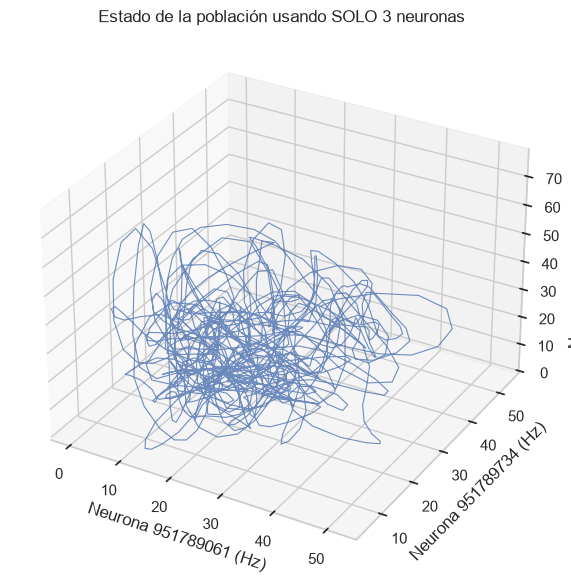

In [16]:
# Elegimos las 3 neuronas más activas para ilustrar el 'espacio de estados' en 3D.
actividad = tasas_suaves.sum(axis=1)
top3      = np.argsort(actividad)[-3:]
etiquetas = [str(unidades_sel.index[i]) for i in top3]

fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(111, projection='3d')
ax.plot(tasas_suaves[top3[0]], tasas_suaves[top3[1]], tasas_suaves[top3[2]],
        lw=0.8, alpha=0.8)
ax.set_xlabel(f'Neurona {etiquetas[0]} (Hz)')
ax.set_ylabel(f'Neurona {etiquetas[1]} (Hz)')
ax.set_zlabel(f'Neurona {etiquetas[2]} (Hz)')
ax.set_title('Estado de la población usando SOLO 3 neuronas')
plt.tight_layout()
plt.show()

---
## Sección 5: Reducción de Dimensionalidad (PCA)

### 5.1. La idea del PCA

El **Análisis de Componentes Principales** busca nuevos ejes (las **componentes principales**) que sean combinaciones lineales de las neuronas y que capturen, en orden, la **máxima varianza** de los datos:

- **PC1** es la dirección del espacio de N dimensiones a lo largo de la cual los estados neuronales varían más.
- **PC2** es la dirección de máxima varianza *restante* que además es perpendicular a PC1.
- ... y así sucesivamente.

Como las neuronas covarían, unas pocas componentes suelen explicar la mayor parte de la varianza. Esas componentes son las **variables latentes**: no las medimos directamente, pero resumen el estado colectivo de la red. Proyectar el estado neuronal sobre PC1, PC2, PC3 nos da coordenadas que **sí** podemos dibujar.

### 5.2. Un paso imprescindible: estandarizar

Antes del PCA, estandarizamos **cada neurona** (media 0, desviación 1). ¿Por qué? Porque el PCA persigue varianza, y una neurona con tasa muy alta tendría una varianza enorme *solo por su escala en Hz*, no porque lleve más información. Al estandarizar (equivale a trabajar con la matriz de **correlaciones** en vez de la de **covarianzas**), damos a cada neurona la misma oportunidad de contribuir.

Orientamos la matriz como `(muestras × características) = (bins × neuronas)`: cada **fila** es un instante (una observación del estado) y cada **columna** una neurona (una variable).

In [17]:
# Orientamos: filas = bins de tiempo (muestras), columnas = neuronas (variables).
X  = tasas_suaves.T
mu = X.mean(axis=0)
sd = X.std(axis=0)
sd[sd == 0] = 1.0          # evitamos dividir por cero (neuronas sin actividad)
Z  = (X - mu) / sd          # z-score por neurona

def calcular_pca(datos, n_comp):
    """Devuelve (puntuaciones, varianza_explicada). Usa sklearn si está; si no, SVD de numpy."""
    if TIENE_SKLEARN:
        modelo = PCA(n_components=n_comp)
        puntuaciones = modelo.fit_transform(datos)
        return puntuaciones, modelo.explained_variance_ratio_
    # SVD: es exactamente lo que hace PCA por dentro.
    datos_c   = datos - datos.mean(axis=0)
    U, S, Vt  = np.linalg.svd(datos_c, full_matrices=False)
    puntuaciones = U * S
    varianzas = S ** 2 / (datos.shape[0] - 1)
    evr       = varianzas / varianzas.sum()
    return puntuaciones[:, :n_comp], evr[:n_comp]

n_comp       = int(min(15, Z.shape[0], Z.shape[1]))
scores, evr  = calcular_pca(Z, n_comp)

print('Forma de las puntuaciones (bins × componentes):', scores.shape)
print('Varianza explicada por PC1, PC2, PC3:', np.round(evr[:3] * 100, 1), '%')
print('Varianza acumulada hasta PC3        :', np.round(evr[:3].sum() * 100, 1), '%')

Forma de las puntuaciones (bins × componentes): (1200, 15)
Varianza explicada por PC1, PC2, PC3: [13.5  8.2  5.1] %
Varianza acumulada hasta PC3        : 26.8 %


### 5.3. ¿Cuántas dimensiones hacen falta? El gráfico de varianza explicada

El **scree plot** muestra cuánta varianza aporta cada componente y cuánta se acumula. Si las primeras 2–3 componentes ya explican una fracción grande de la varianza, es una **prueba empírica** de que la actividad de VISp es de **baja dimensión**: la variedad neuronal existe y podemos resumir el estado de decenas de neuronas con muy pocos números.

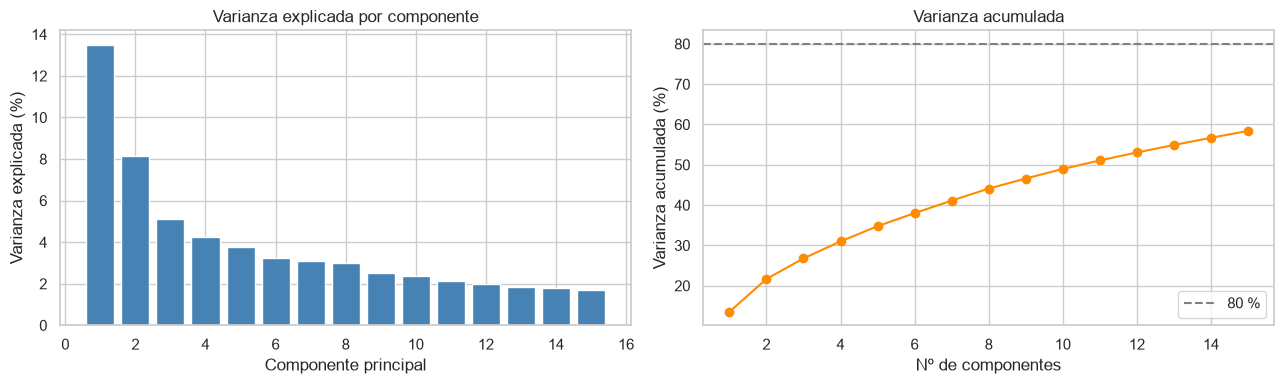

In [18]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))

a1.bar(np.arange(1, len(evr) + 1), evr * 100, color='steelblue')
a1.set_xlabel('Componente principal')
a1.set_ylabel('Varianza explicada (%)')
a1.set_title('Varianza explicada por componente')

a2.plot(np.arange(1, len(evr) + 1), np.cumsum(evr) * 100, 'o-', color='darkorange')
a2.axhline(80, ls='--', color='gray', label='80 %')
a2.set_xlabel('Nº de componentes')
a2.set_ylabel('Varianza acumulada (%)')
a2.set_title('Varianza acumulada')
a2.legend()

plt.tight_layout()
plt.show()

---
## Sección 6: Trayectorias del Estado Neuronal

### 6.1. De puntos a trayectoria

Ya tenemos, para cada instante, sus coordenadas en las componentes principales (`scores`). Si dibujamos PC1 frente a PC2 y **unimos los puntos en orden temporal**, obtenemos la **trayectoria del estado neuronal**: la ruta que sigue la población a través de su espacio latente mientras procesa el estímulo.

Coloreamos cada punto según el **tiempo** para leer la dirección del movimiento. La interpretación es profunda: esa curva suave *es* el cómputo de la red. Estados cercanos en el espacio latente corresponden a patrones de actividad poblacional parecidos; y como el estímulo (las rejillas) tiene estructura temporal repetitiva, es habitual ver trayectorias que **rotan o se repiten**, reflejando que la población vuelve a estados similares ante condiciones similares.

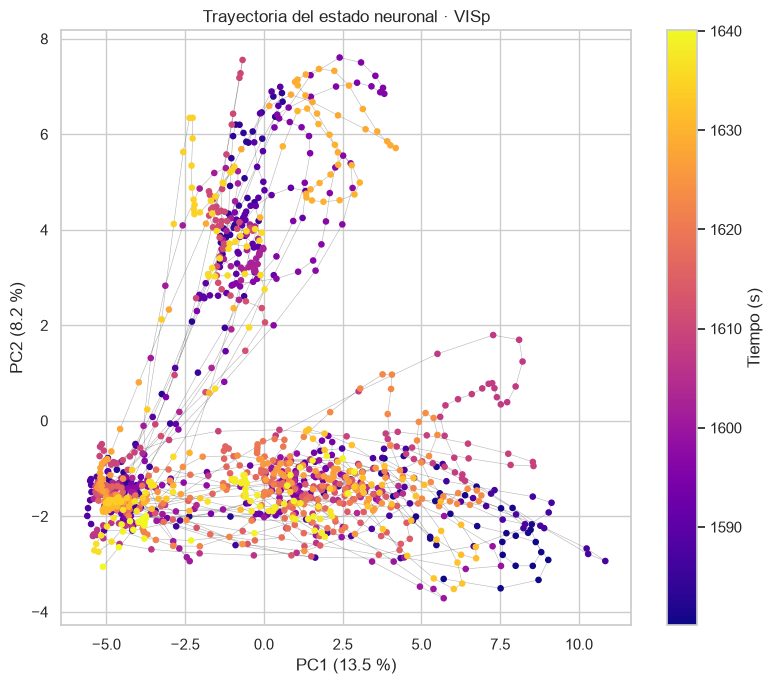

In [19]:
# --- Trayectoria 2D (PC1 vs PC2), coloreada por el tiempo ---
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(scores[:, 0], scores[:, 1], color='gray', lw=0.4, alpha=0.6, zorder=1)
puntos = ax.scatter(scores[:, 0], scores[:, 1], c=centros, cmap='plasma', s=14, zorder=2)
fig.colorbar(puntos, ax=ax, label='Tiempo (s)')
ax.set_xlabel(f'PC1 ({evr[0]*100:.1f} %)')
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f} %)')
ax.set_title(f'Trayectoria del estado neuronal · {REGION_OBJETIVO}')
plt.tight_layout()
plt.show()

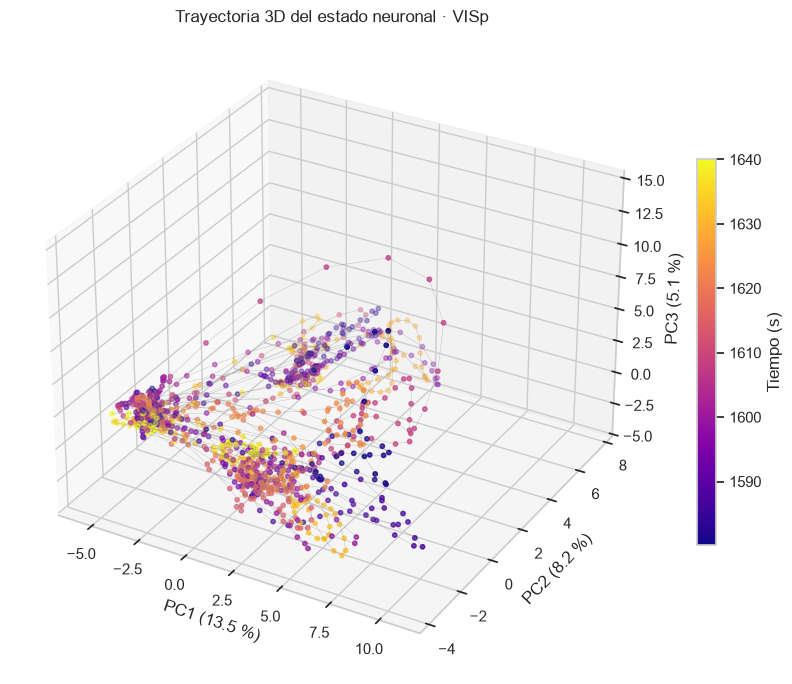

In [20]:
# --- Trayectoria 3D (PC1, PC2, PC3) ---
fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')
ax.plot(scores[:, 0], scores[:, 1], scores[:, 2], color='gray', lw=0.3, alpha=0.5)
p = ax.scatter(scores[:, 0], scores[:, 1], scores[:, 2], c=centros, cmap='plasma', s=10)
fig.colorbar(p, ax=ax, label='Tiempo (s)', shrink=0.6)
ax.set_xlabel(f'PC1 ({evr[0]*100:.1f} %)')
ax.set_ylabel(f'PC2 ({evr[1]*100:.1f} %)')
ax.set_zlabel(f'PC3 ({evr[2]*100:.1f} %)')
ax.set_title(f'Trayectoria 3D del estado neuronal · {REGION_OBJETIVO}')
plt.tight_layout()
plt.show()

---
## Cierre: qué hemos aprendido

Hemos recorrido el camino completo desde el dato más crudo hasta una descripción compacta y visual del cómputo colectivo:

1. **Spikes crudos** de neuronas individuales de VISp (raster).
2. **Tasas de disparo** por binning + suavizado gaussiano → matriz `(neuronas × tiempo)`.
3. Reinterpretación de cada instante como un **punto en un espacio de N dimensiones** (el estado neuronal).
4. **PCA** para hallar las **variables latentes** que resumen ese espacio.
5. **Trayectorias** del estado neuronal en 2D/3D: el retrato de la dinámica de la población.

### La idea de fondo

> Una neurona sola es ruidosa y ambigua; la **población**, en cambio, ocupa una **variedad de baja dimensión** cuya geometría y dinámica reflejan lo que el circuito está computando. El *estado neuronal* es el lenguaje natural para describir esa computación.

### Ideas para seguir explorando

- Colorear la trayectoria por la **condición del estímulo** (p. ej. la orientación de la rejilla) en lugar del tiempo, para ver cómo el estado codifica el estímulo.
- Comparar la dimensionalidad de **distintas regiones** (VISp vs VISl vs LGd) cambiando `REGION_OBJETIVO`.
- Promediar trayectorias sobre repeticiones del mismo estímulo (*trial-averaging*) para reducir el ruido.
- Probar métodos no lineales (t-SNE, UMAP) o específicos de dinámica poblacional (jPCA, GPFA, LFADS).

### Buenas prácticas: cerrar el archivo

Al terminar, cerramos la conexión de streaming para liberar recursos (importante, sobre todo en Windows).

In [ ]:
# Cerramos el archivo NWB y la conexión de streaming.
io.close()
h5_file.close()
rem_file.close()
print('Archivo NWB cerrado. Recursos liberados.')
# by Megaomega

Archivo NWB cerrado. Recursos liberados.
